# **Informe de Análisis de Churn - Telecom X**
## **1. Introducción**
El presente análisis tiene como objetivo estudiar el comportamiento de los clientes de Telecom X para identificar los factores asociados con la evasión (churn). El churn, o abandono del servicio, representa una pérdida de ingresos y un desafío estratégico para la compañía. Comprender qué características diferencian a los clientes que se van de los que permanecen permitirá diseñar acciones de retención más efectivas.

Para ello, se trabajó con un conjunto de datos de clientes que incluye información demográfica, servicios contratados, tipo de contrato, métodos de pago y cargos. El análisis se desarrolló en Python, utilizando las librerías pandas, numpy y matplotlib, siguiendo un flujo de carga, limpieza, exploración y visualización.


---


## **2. Limpieza y Tratamiento de Datos**
Los datos fueron obtenidos desde un archivo JSON alojado en un repositorio público mediante la librería requests. Se utilizó pandas.json_normalize para aplanar la estructura anidada y se renombraron las columnas reemplazando espacios por guiones bajos para facilitar su manipulación.

### **Pasos de limpieza:**

**- Conversión de la variable objetivo Churn:** Se transformó de texto ("Yes"/"No") a valores numéricos (1/0).

**- Estandarización de columnas categóricas:** Se eliminaron espacios en blanco al inicio y final, se convirtió todo a minúsculas y se unificaron formatos (ej. "yes"/"no"). Esto evita inconsistencias como "Yes" vs "yes".

**- Manejo de valores nulos:** Se detectaron 224 valores nulos en la columna Churn. Dado que representan aproximadamente el 3% de los datos, se optó por mantenerlos (en análisis posteriores pandas los ignora por defecto). En las demás columnas no se encontraron nulos inicialmente, pero se aplicó una imputación preventiva: para las numéricas se usó la mediana y para las categóricas se asignó "unknown".

**- Conversión de tipos:** La columna TotalCharges (renombrada como cargo_total) se encontraba como tipo object debido a la presencia de cadenas vacías. Se convirtió a numérico, reemplazando los vacíos por NaN y luego imputando con la mediana.

**- Verificación de duplicados:** No se encontraron filas duplicadas.

**- Creación de nueva variable:** A partir del cargo mensual (cargo_mensual) se calculó Cuentas_Diarias = cargo_mensual / 30, que representa el gasto diario aproximado por cliente. Esta variable puede ser útil para comparar clientes con diferentes duraciones de ciclo de facturación.

Al finalizar este proceso, el conjunto de datos quedó compuesto por 7267 clientes y 22 columnas, sin valores faltantes y con tipos de datos consistentes.

---
## **3. Análisis Exploratorio de Datos (EDA)**
### **3.1 Distribución de la variable objetivo (Churn)**
Se calculó la proporción de clientes que han abandonado el servicio:

**- No churn (0):** 73.5% (aprox. 5343 clientes)

Churn (1): 26.5% (aprox. 1924 clientes)

Esta distribución confirma que el problema es relevante, con más de una cuarta parte de la base de clientes en riesgo de fuga. El gráfico de barras incluido en el notebook ilustra claramente esta disparidad.

### **3.2 Variables más relevantes para predecir churn**
Para identificar qué variables podrían ser buenos predictores, se utilizaron dos enfoques:

Variables numéricas: se calculó la correlación absoluta con Churn. Las de mayor correlación fueron: antiguedad_meses (tenure), cargo_mensual y cargo_total.

Variables categóricas: se midió la diferencia entre la tasa de churn máxima y mínima dentro de cada categoría. Las que mostraron mayor variación fueron: account.Contract, internet.InternetService, account.PaymentMethod y varios servicios adicionales de internet (seguridad, soporte técnico, respaldo, etc.).

La combinación de ambos criterios arrojó que las columnas más prometedoras para el análisis son:
antiguedad_meses, cargo_mensual, adulto_mayor, customerID, cargo_total, account.Contract, internet.InternetService, internet.OnlineSecurity, internet.TechSupport, internet.OnlineBackup, internet.DeviceProtection, account.PaymentMethod e internet.StreamingMovies.

### **3.3 Análisis de variables categóricas clave**
Se examinó la relación entre el churn y tres variables categóricas relevantes mediante tablas de contingencia que muestran el porcentaje de churn dentro de cada categoría.

Género: No se observan diferencias significativas. Las mujeres presentan una tasa de churn del 26.1% y los hombres del 25.3%.

Tipo de contrato: Aquí la diferencia es muy marcada. Los clientes con contrato mes a mes tienen una tasa de churn del 41.3%, mientras que aquellos con contrato de un año bajan al 10.9% y los de dos años solo al 2.8%. Esto sugiere que la duración del contrato es un factor protector: a mayor compromiso, menor probabilidad de fuga.

Método de pago: El método de pago con cheque electrónico presenta la tasa de churn más alta (43.8%), muy por encima de los otros métodos (entre 14.8% y 18.5%). Esto podría indicar que los clientes que usan este medio son menos estables o tienen una relación menos formal con la empresa.

### **3.4 Análisis de variables numéricas**
Se compararon las distribuciones de cargo_total y antiguedad_meses entre clientes que se fueron y los que se quedaron.

Antigüedad en meses:

Clientes sin churn: media de 37.3 meses, mediana 37 meses.

Clientes con churn: media de 17.9 meses, mediana 10 meses.
Es decir, los clientes que abandonan tienen una antigüedad mucho menor. Esto es consistente con la idea de que la fuga es más probable en los primeros meses de relación.

Cargo total acumulado:

Sin churn: media $2540, mediana $1669.

Con churn: media $1531, mediana $703.
Los clientes que se van han gastado menos en total, lo que es lógico dado su menor tiempo de permanencia. Sin embargo, la diferencia en medianas es especialmente pronunciada, lo que refuerza que la baja antigüedad es un factor determinante.

### **3.5 Visualizaciones adicionales sugeridas**
Si bien el notebook incluye un gráfico de barras para la distribución del churn, sería enriquecedor incorporar:

Boxplots de antiguedad_meses y cargo_total segmentados por churn, para visualizar la dispersión y posibles valores atípicos.

Gráficos de barras apiladas para las variables categóricas clave, mostrando la proporción de churn en cada categoría.

Un mapa de calor de correlaciones entre variables numéricas para detectar posibles relaciones (por ejemplo, entre cargo mensual y total).

---

## **4. Conclusiones e Insights**
A partir del análisis realizado, se pueden extraer las siguientes conclusiones principales:

El tipo de contrato es el factor más diferenciador. Los clientes con contratos de largo plazo (uno o dos años) son mucho más leales. La empresa debería priorizar estrategias que incentiven la migración de contratos mes a mes a planes de mayor duración.

La antigüedad del cliente es crítica. Los primeros meses son los de mayor riesgo de abandono. Esto sugiere la necesidad de un programa de onboarding sólido y un seguimiento intensivo durante el primer año.

El método de pago está fuertemente asociado al churn. Quienes pagan con cheque electrónico tienen una propensión a irse muy superior al resto. Podría investigarse si este método está relacionado con perfiles de clientes menos estables o si la experiencia de pago es deficiente.

Los servicios adicionales de internet (seguridad, soporte técnico, respaldo, etc.) aparecen como relevantes. Aunque no se profundizó, esto indica que el tipo de servicios contratados influye en la fidelidad. Es posible que los clientes que contratan más servicios (o ciertos servicios específicos) tengan un mayor apego.

No se encontraron diferencias relevantes por género, lo que sugiere que las acciones de retención pueden ser transversales en este aspecto.

Librerias que usa el proyecto

In [41]:
import requests
import pandas as pd
import numpy as np

✅ Cargar los datos directamente desde la API utilizando Python.

✅ Convertir los datos a un DataFrame de Pandas para facilitar su manipulación.

In [42]:
API_URL = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

resp = requests.get(API_URL, timeout=30)
resp.raise_for_status()
data = resp.json()

df = pd.json_normalize(data)
df.columns = [c.replace(" ", "_") for c in df.columns]

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


✅ Explorar las columnas del dataset y verificar sus tipos de datos.

In [43]:
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


✅ Consultar el diccionario para comprender mejor el significado de las variables.

In [44]:
DICT_URL = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_diccionario.md"

dic = requests.get(DICT_URL, timeout=30)
dic.raise_for_status()
dic_md = dic.text

print(dic_md)

#### Diccionario de datos

- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `tenure`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de streaming de películas
- `Contract`: t

✅ Identificar las columnas más relevantes para el análisis de evasión.

In [45]:
if df["Churn"].dtype == "object":
    df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

y = df["Churn"]

num_cols = df.select_dtypes(include=[np.number]).columns.drop("Churn", errors="ignore")
cat_cols = df.select_dtypes(include=["object", "bool"]).columns

num_score = df[num_cols].corrwith(y).abs().sort_values(ascending=False)

cat_score = pd.Series(
    {c: df.groupby(c)["Churn"].mean().max() - df.groupby(c)["Churn"].mean().min() for c in cat_cols}
).sort_values(ascending=False)

top_num = num_score.head(10)
top_cat = cat_score.head(10)

relevantes = pd.Index(top_num.index.tolist() + top_cat.index.tolist()).unique().tolist()
print("Columnas más relevantes:", relevantes)

Columnas más relevantes: ['customer.tenure', 'account.Charges.Monthly', 'customer.SeniorCitizen', 'customerID', 'account.Charges.Total', 'account.Contract', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.TechSupport', 'internet.OnlineBackup', 'internet.DeviceProtection', 'account.PaymentMethod', 'internet.StreamingMovies']


Verificacion errores en datos

In [46]:
# faltantes, duplicados, tipos y categorías inconsistentes (solo pandas)
print(df.isna().sum().sort_values(ascending=False).head(15))
print("Duplicados:", df.duplicated().sum())

cat_cols = df.select_dtypes(include="object").columns
df[cat_cols] = df[cat_cols].apply(lambda s: s.astype(str).str.strip().str.lower())
print(df[cat_cols].nunique().sort_values(ascending=False).head(15))

Churn                        224
customerID                     0
customer.gender                0
customer.SeniorCitizen         0
customer.Partner               0
customer.Dependents            0
customer.tenure                0
phone.PhoneService             0
phone.MultipleLines            0
internet.InternetService       0
internet.OnlineSecurity        0
internet.OnlineBackup          0
internet.DeviceProtection      0
internet.TechSupport           0
internet.StreamingTV           0
dtype: int64
Duplicados: 0
customerID                   7267
account.Charges.Total        6531
account.PaymentMethod           4
internet.OnlineBackup           3
internet.OnlineSecurity         3
internet.TechSupport            3
internet.DeviceProtection       3
internet.InternetService        3
phone.MultipleLines             3
internet.StreamingMovies        3
internet.StreamingTV            3
account.Contract                3
phone.PhoneService              2
customer.gender                 2
cu

Correccion para datos coherentes


In [49]:
df = df.drop_duplicates().copy()

cat_cols = df.select_dtypes(include="object").columns
df[cat_cols] = df[cat_cols].apply(lambda s: s.astype(str).str.strip().str.lower())

if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].replace({"": pd.NA, "nan": pd.NA}), errors="coerce")

num_cols = df.select_dtypes(include="number").columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna("unknown")

print("dimensiones:", df.shape)
print("faltantes totales:", int(df.isna().sum().sum()))
df.head()

dimensiones: (7267, 21)
faltantes totales: 0


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-orfbo,0.0,female,0,yes,yes,9,yes,no,dsl,...,yes,no,yes,yes,no,one year,yes,mailed check,65.6,593.3
1,0003-mknfe,0.0,male,0,no,no,9,yes,yes,dsl,...,no,no,no,no,yes,month-to-month,no,mailed check,59.9,542.4
2,0004-tlhlj,1.0,male,0,no,no,4,yes,no,fiber optic,...,no,yes,no,no,no,month-to-month,yes,electronic check,73.9,280.85
3,0011-igkff,1.0,male,1,yes,no,13,yes,no,fiber optic,...,yes,yes,no,yes,yes,month-to-month,yes,electronic check,98.0,1237.85
4,0013-exchz,1.0,female,1,yes,no,3,yes,no,fiber optic,...,no,no,yes,yes,no,month-to-month,yes,mailed check,83.9,267.4


Columna Cuentas Diarias

In [53]:
df["Cuentas_Diarias"] = df["account.Charges.Monthly"] / 30
df[["account.Charges.Monthly", "Cuentas_Diarias"]].head()

,account.Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


Traduccion binaria de columnas

In [56]:
yn_cols = [
    "Churn","customer.Partner","customer.Dependents","account.PaperlessBilling",
    "phone.PhoneService","internet.OnlineSecurity","internet.OnlineBackup",
    "internet.DeviceProtection","internet.TechSupport","internet.StreamingTV",
    "internet.StreamingMovies"
]
for c in yn_cols:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip().str.lower().map(
            {"yes":1,"no":0,"si":1,"sí":1,"no ":0}
        ).fillna(df[c])

df = df.rename(columns={
    "customerID":"cliente_id",
    "customer.gender":"genero",
    "customer.SeniorCitizen":"adulto_mayor",
    "customer.tenure":"antiguedad_meses",
    "account.Charges.Monthly":"cargo_mensual",
    "account.Charges.Total":"cargo_total"
})
print(df.head())
print(df.dtypes)

   cliente_id  Churn  genero  adulto_mayor  customer.Partner  \
0  0002-orfbo    0.0  female             0               1.0   
1  0003-mknfe    0.0    male             0               0.0   
2  0004-tlhlj    1.0    male             0               0.0   
3  0011-igkff    1.0    male             1               1.0   
4  0013-exchz    1.0  female             1               1.0   

   customer.Dependents  antiguedad_meses  phone.PhoneService  \
0                  1.0                 9                 1.0   
1                  0.0                 9                 1.0   
2                  0.0                 4                 1.0   
3                  0.0                13                 1.0   
4                  0.0                 3                 1.0   

  phone.MultipleLines internet.InternetService  ... internet.DeviceProtection  \
0                  no                      dsl  ...                       0.0   
1                 yes                      dsl  ...                 

Media, Mediana y Desviacion estandar

In [58]:
desc_num = df.describe().T
desc_num["median"] = df.median(numeric_only=True)
desc_num[["mean","median","std","min","max"]]

,mean,median,std,min,max
Churn,0.257190,0.000000,0.437115,0.000000,1.000000
adulto_mayor,0.162653,0.000000,0.369074,0.000000,1.000000
customer.Partner,0.484106,0.000000,0.499782,0.000000,1.000000
customer.Dependents,0.300124,0.000000,0.458343,0.000000,1.000000
antiguedad_meses,32.346498,29.000000,24.571773,0.000000,72.000000
phone.PhoneService,0.902711,1.000000,0.296371,0.000000,1.000000
account.PaperlessBilling,0.593230,1.000000,0.491265,0.000000,1.000000
cargo_mensual,64.720098,70.300000,30.129572,18.250000,118.750000
Cuentas_Diarias,2.157337,2.343333,1.004319,0.608333,3.958333


Distribucion de la variable Churn

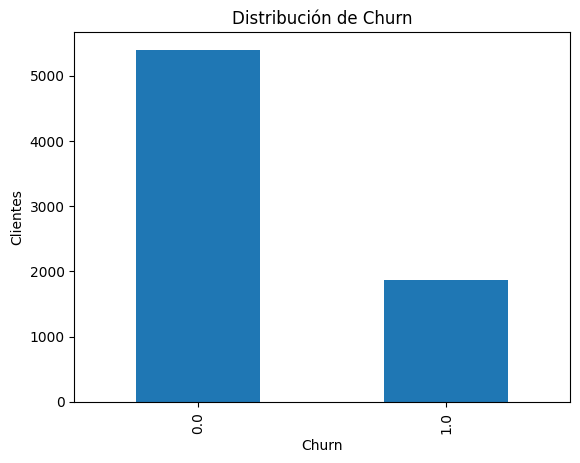

,proportion
Churn,
0.0,74.28
1.0,25.72


In [59]:
import matplotlib.pyplot as plt

counts = df["Churn"].value_counts()
counts.plot(kind="bar")
plt.title("Distribución de Churn")
plt.xlabel("Churn")
plt.ylabel("Clientes")
plt.show()

(df["Churn"].value_counts(normalize=True)*100).round(2)

Distribucion de la evacion segun varibles como genero, tipo de contrato, metodos de pago

In [60]:
for col in ["genero", "account.Contract", "account.PaymentMethod"]:
    if col in df.columns:
        print("\n", col)
        print(pd.crosstab(df[col], df["Churn"], normalize="index").round(3))


 genero
Churn     0.0    1.0
genero              
female  0.739  0.261
male    0.747  0.253

 account.Contract
Churn               0.0    1.0
account.Contract              
month-to-month    0.587  0.413
one year          0.891  0.109
two year          0.972  0.028

 account.PaymentMethod
Churn                        0.0    1.0
account.PaymentMethod                  
bank transfer (automatic)  0.838  0.162
credit card (automatic)    0.852  0.148
electronic check           0.562  0.438
mailed check               0.815  0.185


EXPLORACION DE VARIABLES NUMERICAS: TOTAL GASTADO, TIEMPO DE CONTRATO

In [61]:
col_total = "cargo_total" if "cargo_total" in df.columns else "account.Charges.Total"
df[col_total] = pd.to_numeric(df[col_total], errors="coerce")

# compara numéricas por churn
for col in [col_total, "antiguedad_meses"]:
    if col in df.columns:
        print("\n", col)
        print(df.groupby("Churn")[col].describe()[["count","mean","50%","std","min","max"]])


 cargo_total
        count         mean      50%          std    min      max
Churn                                                           
0.0    5387.0  2540.440867  1669.40  2330.360507  18.80  8672.45
1.0    1869.0  1531.796094   703.55  1890.822994  18.85  8684.80

 antiguedad_meses
        count       mean   50%        std  min   max
Churn                                               
0.0    5398.0  37.321045  37.0  24.178367  0.0  72.0
1.0    1869.0  17.979133  10.0  19.531123  1.0  72.0
